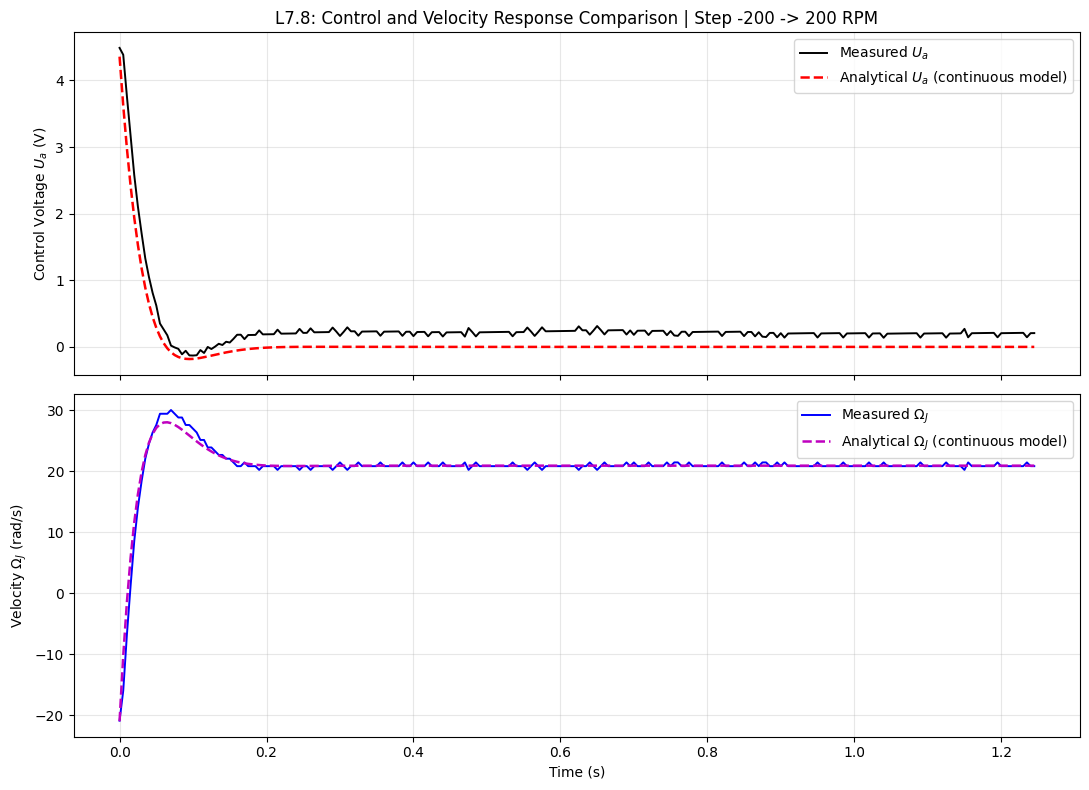

=== L7.8 Summary ===
CSV file: Lab7.csv
Kp = 0.104000, Ki = 2.070000, BTI = 5.000 ms
Reference step: -200.00 RPM -> 200.00 RPM
Velocity RMSE (rad/s): 0.7748
Control RMSE (V): 0.2351
Conclusion: Measured and analytical velocity responses agree well overall. Small deviations are consistent with sampling, sensor noise, and hardware nonidealities.


In [1]:
# L7.8 Analysis: Compare measured and analytical responses for a -200 -> +200 RPM reference step

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal


def load_lab7_csv(csv_path: Path):
    """Load metadata + timeseries from the Lab7 capture CSV format."""
    lines = csv_path.read_text().splitlines()

    # Parse header metadata block (key,value) up to the first blank line.
    meta = {}
    data_header_idx = None
    for i, line in enumerate(lines):
        if line.startswith("Sample,"):
            data_header_idx = i
            break
        if "," in line and line.strip() and not line.startswith("Sample"):
            key, value = line.split(",", 1)
            meta[key.strip()] = value.strip()

    if data_header_idx is None:
        raise ValueError("Could not locate timeseries header line starting with 'Sample,'.")

    df = pd.read_csv(csv_path, skiprows=data_header_idx)
    for col in ["Sample", "Omega_J_rad_s", "Ua"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=["Sample", "Omega_J_rad_s", "Ua"]).reset_index(drop=True)

    return meta, df


def to_float(meta, key, default):
    try:
        return float(meta.get(key, default))
    except (TypeError, ValueError):
        return float(default)


# -----------------------------------------------------------------------------
# Load measured data
# -----------------------------------------------------------------------------
csv_path = Path("Lab7.csv")
if not csv_path.exists():
    # Fallback if notebook is opened from a different working directory.
    csv_path = Path("data") / "Lab7.csv"

meta, df = load_lab7_csv(csv_path)

# Metadata from capture
Kp = to_float(meta, "Kp", 0.104)
Ki = to_float(meta, "Ki", 2.07)
BTI_ms = to_float(meta, "BTI", 5.0)
omega_ref_now = to_float(meta, "CurrentOmegaR_rad_s", 20.943951)
omega_ref_prev = to_float(meta, "PreviousOmegaR_rad_s", -20.943951)

# Time vector from sample index and BTI
t = df["Sample"].to_numpy() * (BTI_ms / 1000.0)
omega_meas = df["Omega_J_rad_s"].to_numpy()
ua_meas = df["Ua"].to_numpy()

# -----------------------------------------------------------------------------
# Analytical continuous closed-loop model (Lab 7 approximation)
# Plant: Gp(s) = Ka*Km / (J*s + B)
# PI:    C(s)  = Kp + Ki/s
#
# Closed-loop (reference -> velocity):
# Omega(s)/R(s) = (Ka*Km*(Kp*s + Ki)) / (J*s^2 + (B + Ka*Km*Kp)*s + Ka*Km*Ki)
#
# Closed-loop (reference -> control voltage):
# Ua(s)/R(s) = ((Kp*s + Ki)*(J*s + B)) / (J*s^2 + (B + Ka*Km*Kp)*s + Ka*Km*Ki)
# -----------------------------------------------------------------------------
Ka = 0.06
Km = 0.0698
J = 7.8e-6
B = 0.0

den = [J, B + Ka * Km * Kp, Ka * Km * Ki]
num_omega = [Ka * Km * Kp, Ka * Km * Ki]
num_ua = [J * Kp, J * Ki + B * Kp, B * Ki]

sys_omega = signal.TransferFunction(num_omega, den)
sys_ua = signal.TransferFunction(num_ua, den)

# Simulate a unit step and then scale to the captured reference step.
_, y_omega_unit = signal.step(sys_omega, T=t)
_, y_ua_unit = signal.step(sys_ua, T=t)

delta_ref = omega_ref_now - omega_ref_prev
omega_theory = omega_ref_prev + delta_ref * y_omega_unit

# Approximate pre-step control offset from DC plant relation when B != 0.
ua_prev = 0.0 if abs(B) < 1e-12 else (B / (Ka * Km)) * omega_ref_prev
ua_theory = ua_prev + delta_ref * y_ua_unit

# -----------------------------------------------------------------------------
# Metrics + plotting
# -----------------------------------------------------------------------------
rmse_omega = np.sqrt(np.mean((omega_meas - omega_theory) ** 2))
rmse_ua = np.sqrt(np.mean((ua_meas - ua_theory) ** 2))

rad_s_to_rpm = 60.0 / (2.0 * np.pi)
step_prev_rpm = omega_ref_prev * rad_s_to_rpm
step_now_rpm = omega_ref_now * rad_s_to_rpm

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

axes[0].plot(t, ua_meas, "k", lw=1.4, label="Measured $U_a$")
axes[0].plot(t, ua_theory, "r--", lw=1.8, label="Analytical $U_a$ (continuous model)")
axes[0].set_ylabel("Control Voltage $U_a$ (V)")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="best")
axes[0].set_title(
    f"L7.8: Control and Velocity Response Comparison | "
    f"Step {step_prev_rpm:.0f} -> {step_now_rpm:.0f} RPM"
)

axes[1].plot(t, omega_meas, "b", lw=1.4, label="Measured $\\Omega_J$")
axes[1].plot(t, omega_theory, "m--", lw=1.8, label="Analytical $\\Omega_J$ (continuous model)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Velocity $\\Omega_J$ (rad/s)")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

print("=== L7.8 Summary ===")
print(f"CSV file: {csv_path}")
print(f"Kp = {Kp:.6f}, Ki = {Ki:.6f}, BTI = {BTI_ms:.3f} ms")
print(f"Reference step: {step_prev_rpm:.2f} RPM -> {step_now_rpm:.2f} RPM")
print(f"Velocity RMSE (rad/s): {rmse_omega:.4f}")
print(f"Control RMSE (V): {rmse_ua:.4f}")

if rmse_omega < 1.0:
    conclusion = (
        "Measured and analytical velocity responses agree well overall. "
        "Small deviations are consistent with sampling, sensor noise, and hardware nonidealities."
    )
else:
    conclusion = (
        "Measured and analytical responses show noticeable differences. "
        "Likely causes include unmodeled friction, actuator limits, discretization effects, and measurement noise."
    )

print("Conclusion:", conclusion)
